# Classificação Automática de Notícias Moçambicanas

Este projecto tem como objectivo desenvolver e avaliar modelos de ML capazes de classificar automaticamente notícias em diferentes categorias temáticas, utilizando técnicas de Processamento de Linguagem Natural.

Para alcançar este objectivo, foi utilizado um conjunto de dados composto por notícias moçambicanas previamente categorizadas em diferentes classes temáticas. Os dados passaram por etapas de limpeza, preparação e transformação textual, incluindo técnicas de pré-processamento adequadas para textos em língua portuguesa. Posteriormente, foram aplicadas técnicas de extracção de características baseadas em TF-IDF, seguidas da construção e avaliação de diferentes modelos de classificação supervisionada.

Ao longo do projecto são realizadas análises exploratórias dos dados, avaliações comparativas dos modelos desenvolvidos e interpretações dos resultados obtidos, com o propósito de identificar a abordagem mais eficaz para a classificação automática de notícias moçambicanas.

## Objectivos Específicos

* Realizar a limpeza, transformação e preparação dos textos para melhorar a qualidade dos dados utilizados no treino dos modelos.
* Explorar o conjunto de dados através de técnicas de Análise Exploratória de Dados (EDA).
* Aplicar técnicas de Processamento de Linguagem Natural para representação textual das notícias.
* Construir modelos de classificação supervisionada utilizando algoritmos de Machine Learning.
* Comparar o desempenho de diferentes modelos de classificação.
* Identificar o modelo mais adequado para a classificação automática de notícias moçambicanas.
* Produzir conclusões e recomendações para trabalhos futuros na área de classificação de textos.

---

<img src="../assets/capa iii.png">

---

# *I. Base*

### Bibliotecas Usadas

In [218]:
# BIBLIOTECAS PADRÃO
import os
import math
import warnings
from collections import Counter

warnings.filterwarnings("ignore")

# MANIPULAÇÃO DE DADOS
import pandas as pd
import numpy as np

# VISUALIZAÇÃO DE DADOS
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# PROCESSAMENTO DE LINGUAGEM NATURAL (NLP)
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# MACHINE LEARNING - PRÉ-PROCESSAMENTO
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# MACHINE LEARNING - MODELOS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# MACHINE LEARNING - PIPELINES E REDUÇÃO DE DIMENSIONALIDADE
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# MACHINE LEARNING - AVALIAÇÃO
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

### Funções Principais

In [219]:
def analisar_qualidade(df, df_caminho):
    """
    Realiza uma análise básica da qualidade de um dataset,
    apresentando informações sobre dimensões, uso de memória,
    valores ausentes, duplicados, tipos de dados e estatísticas
    descritivas das colunas numéricas.
    """
    
    # Dimensões básicas
    total_linhas = df.shape[0]
    total_colunas = df.shape[1]
    total_celulas = total_linhas * total_colunas
    
    # Tamanho em memória
    tamanho_mb_dico = os.path.getsize(df_caminho) / 1024**2
    tamanho_mb_memoria = df.memory_usage(deep=True).sum() / (1024 ** 2)
    
    
    # Valores ausentes
    valores_ausentes = df.isnull().sum().sum()
    percentagem_ausentes = (valores_ausentes / total_celulas) * 100
    
    # Duplicados
    duplicados = df.duplicated().sum()
    percentagem_duplicados = (duplicados / total_linhas) * 100
    
    # Dados válidos
    dados_validos = total_celulas - valores_ausentes
    percentagem_validos = (dados_validos / total_celulas) * 100
    
    # Linhas completas (sem valores ausentes)
    linhas_completas = df.dropna().shape[0]
    percentagem_linhas_completas = (linhas_completas / total_linhas) * 100
    
    # Linhas incompletas (com valores ausentes)
    linhas_incompletas = total_linhas - linhas_completas
    percentagem_linhas_incompletas = (linhas_incompletas / total_linhas) * 100
    
    # EXIBIÇÃO DE RESULTADOS
    print("=" * 70)
    print("ANÁLISE DE QUALIDADE DO DATASET")
    print("=" * 70)
    
    # Detalhes gerais
    print("\n DETALHES GERAIS")
    print("-" * 70)
    print(f"Total de linhas: {total_linhas:,}")
    print(f"Total de colunas: {total_colunas}")
    print(f"Total de células: {total_celulas:,}")
    print(f"Tamanho do dataset (em disco): {tamanho_mb_dico:.1f} MB")
    print(f"Tamanho do dataset (em memória): {tamanho_mb_memoria:.1f} MB")
    
    # Tabela de métricas principais
    print("\n RESUMO DA QUALIDADE DOS DADOS")
    print("-" * 70)
    
    metricas = pd.DataFrame({
        "Métrica": [
            "Valores ausentes",
            "Duplicados",
            "Dados válidos",
            "Linhas completas",
            "Linhas incompletas"
        ],
        "Quantidade": [
            valores_ausentes,
            duplicados,
            dados_validos,
            linhas_completas,
            linhas_incompletas
        ],
        "Percentagem (%)": [
            f"{percentagem_ausentes:.1f}%",
            f"{percentagem_duplicados:.1f}%",
            f"{percentagem_validos:.1f}%",
            f"{percentagem_linhas_completas:.1f}%",
            f"{percentagem_linhas_incompletas:.1f}%"
        ]
    })
    
    print(metricas.to_string(index=False))
    
    # Valores ausentes por coluna
    print("\n VALORES AUSENTES POR COLUNA")
    print("-" * 70)
    
    ausentes_coluna = df.isnull().sum()
    percentagem_coluna = (ausentes_coluna / total_linhas) * 100
    
    tabela_ausentes = pd.DataFrame({
        "Coluna": df.columns,
        "Valores Ausentes": ausentes_coluna.values,
        "Percentagem (%)": [f"{p:.1f}%" for p in percentagem_coluna.values]
    })
    
    print(tabela_ausentes.to_string(index=False))
    
    # Tipos de dados
    print("\n TIPOS DE DADOS")
    print("-" * 70)
    print(df.dtypes)
    
# ============================================================================================

def plotar_categorias(df):
    """
    Gera um gráfico de barras para visualizar a distribuição das classes
    presentes no conjunto de dados.
    """
    
    # Contagens
    contagens = df['CLASSE'].value_counts().sort_values(ascending=False)
    
    # Percentagens
    percentagens = (contagens / contagens.sum()) * 100
    
    # DataFrame para facilitar
    df_plot = pd.DataFrame({
        'Classe': contagens.index,
        'Amostras': contagens.values,
        'Percentagem': percentagens.values
    })
    
    # Estilo
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    
    # Paleta marinha
    paleta_marinha = sns.color_palette(
        ["#003B5C", "#005F73", "#0A9396", "#94D2BD", "#3A86A8", "#0077B6"]
    )
    
    ax = sns.barplot(
        data=df_plot,
        x='Classe',
        y='Amostras',
        palette=paleta_marinha
    )
    
    # Título e eixos
    plt.title('Distribuição das Classes', fontsize=16, fontweight='bold')
    plt.xlabel('Classe', fontsize=12)
    plt.ylabel('Número de Amostras', fontsize=12)
    
    # Adicionar labels nas barras
    for i, row in enumerate(df_plot.itertuples()):
        ax.text(
            i,
            row.Amostras,
            f'{row.Amostras:,}\n({row.Percentagem:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )
    
    # Melhorar aparência
    sns.despine()
    plt.tight_layout()
    
    plt.show()

# ============================================================================================

def plotar_histograma_palavras(df):
    """
    Gera um histograma para visualizar a distribuição do número de palavras
    presentes nas notícias do conjunto de dados.
    """
    
    media = df["NR_PALAVRAS"].mean()
    mediana = df["NR_PALAVRAS"].median()
    
    plt.figure(figsize=(10, 6))
    
    sns.histplot(
        data=df,
        x="NR_PALAVRAS",
        bins=30,
        kde=True,
        color="#005F73",
        edgecolor="white",
        alpha=0.85
    )
    
    plt.axvline(
        media,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Média = {media:.1f}"
    )
    
    plt.axvline(
        mediana,
        color="orange",
        linestyle=":",
        linewidth=2,
        label=f"Mediana = {mediana:.1f}"
    )
    
    plt.title(
        "Distribuição do Número de Palavras por Notícia",
        fontsize=16,
        fontweight="bold"
    )
    
    plt.xlabel("Número de Palavras", fontsize=12)
    plt.ylabel("Frequência", fontsize=12)
    
    plt.legend()
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    
    plt.tight_layout()
    plt.show()

# ============================================================================================

def plotar_box_palavras(df):
    """
    Gera um gráfico boxplot para comparar a distribuição do número de
    palavras entre as diferentes categorias de notícias.
    """
    
    ordem = (
        noticias
        .groupby("CLASSE")["NR_PALAVRAS"]
        .median()
        .sort_values(ascending=False)
        .index
    )
    
    plt.figure(figsize=(11, 6))
    
    sns.boxplot(
        data=noticias,
        x="CLASSE",
        y="NR_PALAVRAS",
        order=ordem,
        color="#005F73"
    )
    
    plt.title(
        "Distribuição do Número de Palavras por Categoria de Notícia",
        fontsize=16,
        fontweight="bold"
    )
    
    plt.xlabel("Categoria", fontsize=12)
    plt.ylabel("Número de Palavras", fontsize=12)
    
    plt.xticks(rotation=0)
    
    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )
    
    plt.tight_layout()
    plt.show()


---

# *II. Descrição*

In [220]:
# Caminho do dataset
caminho_noticias = "data/raw/noticias nacionais.csv"

---
## Notícias Nacionais

**Contexto:** Dataset com mais de 3.000 notícias de **fontes públicas** de Moçambique.

**Período:** Fevereiro de 2025 á Junho de 2026. 


In [221]:
noticias = pd.read_csv(caminho_noticias)

In [222]:
noticias.head()

,CLASSE,ARTIGO
0,SOCIEDADE,Mais de 30 médicos estagiários manifestaram-se...
1,INTERNACIONAL,Donald Trump e a Presidente da Comissão Europe...
2,INTERNACIONAL,"Nicolas Sarkozy torna-se, esta terça-feira, no..."
3,ECONOMIA,A Inspecção Nacional das Actividades Económica...
4,INTERNACIONAL,"O Papa Francisco sofreu, esta segunda-feira, d..."


---

### Qualidade dos Dados

In [223]:
# Analisar a qualidade do dataset
analisar_qualidade(noticias, caminho_noticias)

ANÁLISE DE QUALIDADE DO DATASET

 DETALHES GERAIS
----------------------------------------------------------------------
Total de linhas: 3,831
Total de colunas: 2
Total de células: 7,662
Tamanho do dataset (em disco): 8.2 MB
Tamanho do dataset (em memória): 14.8 MB

 RESUMO DA QUALIDADE DOS DADOS
----------------------------------------------------------------------
           Métrica  Quantidade Percentagem (%)
  Valores ausentes           9            0.1%
        Duplicados          20            0.5%
     Dados válidos        7653           99.9%
  Linhas completas        3822           99.8%
Linhas incompletas           9            0.2%

 VALORES AUSENTES POR COLUNA
----------------------------------------------------------------------
Coluna  Valores Ausentes Percentagem (%)
CLASSE                 0            0.0%
ARTIGO                 9            0.2%

 TIPOS DE DADOS
----------------------------------------------------------------------
CLASSE    str
ARTIGO    str
dtype: o

---
# *III. Limpeza e Engenharia*

### Limpar valores nulos e duplicados

In [224]:
noticias[noticias['ARTIGO'].isna()].head()

,CLASSE,ARTIGO
335,SOCIEDADE,NaN
638,SOCIEDADE,NaN
1333,ECONOMIA,NaN
1409,DESPORTO,NaN
1677,DESPORTO,NaN


In [225]:
noticias[noticias['ARTIGO'].duplicated(keep=False)].sort_values('ARTIGO').head()

,CLASSE,ARTIGO
1723,SOCIEDADE,"A estrada que liga Pemba a Montepuez, as duas ..."
1452,SOCIEDADE,"A estrada que liga Pemba a Montepuez, as duas ..."
1986,SOCIEDADE,A província de Maputo registou redução de caso...
2141,SOCIEDADE,A província de Maputo registou redução de caso...
2659,DESPORTO,"A selecção ganesa volta a uma fase final, quat..."


In [226]:
# Eliminar nulos e duplicados
noticias = noticias.dropna(subset=['ARTIGO']).drop_duplicates(subset=['ARTIGO'])

print(f"Total de linhas: {len(noticias)}")
print(f"Valores nulos: {noticias['ARTIGO'].isna().sum()}")
print(f"Valores duplicados: {noticias['ARTIGO'].duplicated().sum()}")

Total de linhas: 3805
Valores nulos: 0
Valores duplicados: 0


### Adicionar colunas

In [227]:
# Contagem de caracteres e palavras
noticias["NR_CARACTERES"] = noticias["ARTIGO"].str.len()

noticias["NR_PALAVRAS"] = noticias["ARTIGO"].apply(
    lambda x: len(str(x).split())
)

---
# *IV. Análise Exploratória de Dados (EDA)*

In [228]:
noticias.head()

,CLASSE,ARTIGO,NR_CARACTERES,NR_PALAVRAS
0,SOCIEDADE,Mais de 30 médicos estagiários manifestaram-se...,2554,377
1,INTERNACIONAL,Donald Trump e a Presidente da Comissão Europe...,1384,228
2,INTERNACIONAL,"Nicolas Sarkozy torna-se, esta terça-feira, no...",1057,161
3,ECONOMIA,A Inspecção Nacional das Actividades Económica...,1893,277
4,INTERNACIONAL,"O Papa Francisco sofreu, esta segunda-feira, d...",677,110


### Distribuição das classes

Neste dataset a distribuição das classes mostra uma predominância significativa das notícias da classe SOCIEDADE em relação às demais categorias, o que pode influenciar o desempenho dos modelos que vamos desenvolver. Por isso devemos garantir o uso de métricas de avaliação adequadas.

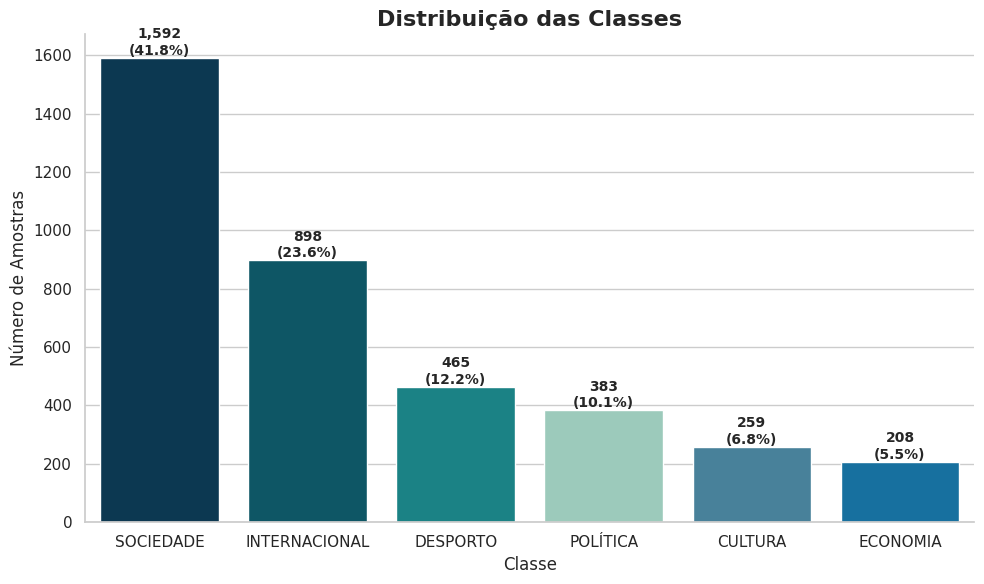

In [229]:
plotar_categorias(noticias)

### Distribuição do nr. de palavras

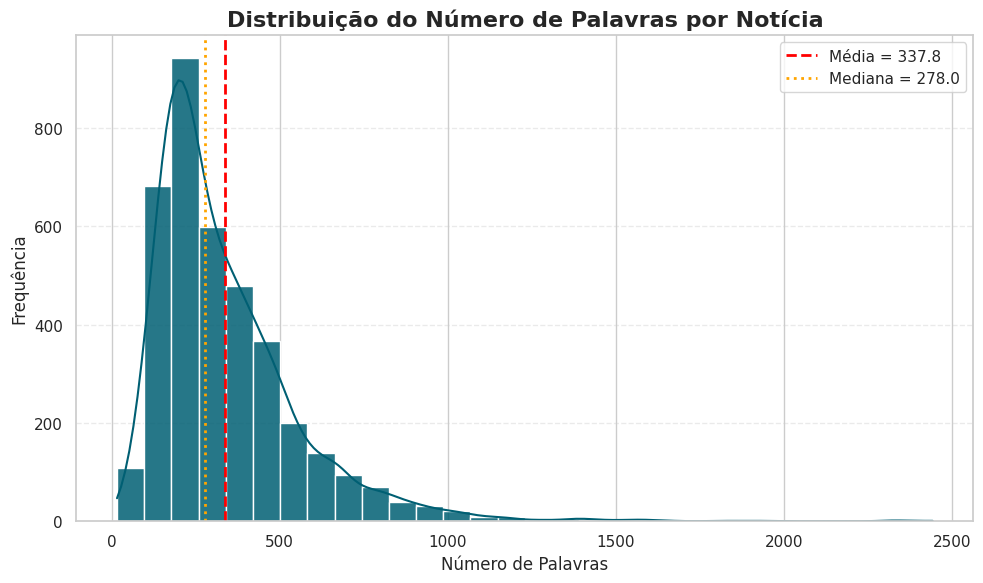

In [230]:
plotar_histograma_palavras(noticias)

### Distribuição Boxplot

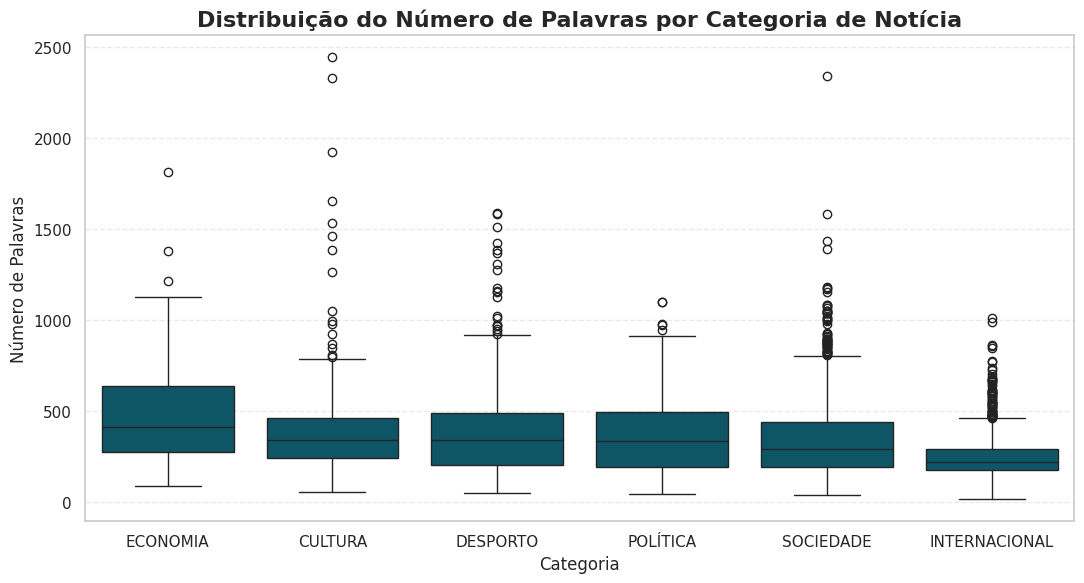

In [231]:
plotar_box_palavras(df)

### WordCloud
---

Este trecho de código tem como objectivo carregar a lista de **stopwords da língua portuguesa** disponibilizada pela biblioteca NLTK (Natural Language Toolkit). 

Inicialmente, a instrução `nltk.download('stopwords')` descarrega, caso ainda não esteja disponível localmente, o conjunto de palavras consideradas pouco informativas para tarefas de Processamento de Linguagem Natural (PLN). 

Em seguida, `stopwords.words('portuguese')` obtém a lista de stopwords em português, contendo palavras frequentes como *"de"*, *"a"*, *"o"*, *"e"*, *"que"*, *"para"*, entre outras. Por fim, a função `set()` converte essa lista num conjunto (`stop_words`), permitindo pesquisas mais rápidas durante o pré-processamento dos textos. 

A remoção dessas palavras é uma etapa comum na preparação de dados textuais, pois reduz o ruído e permite que o modelo concentre a sua aprendizagem nos termos mais relevantes para a classificação das notícias.


In [232]:
nltk.download('stopwords')

stop_words = set(stopwords.words('portuguese'))

[nltk_data] Downloading package stopwords to /home/zauzau/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


----

In [233]:
texto = " ".join(
    noticias["ARTIGO"].astype(str)
)

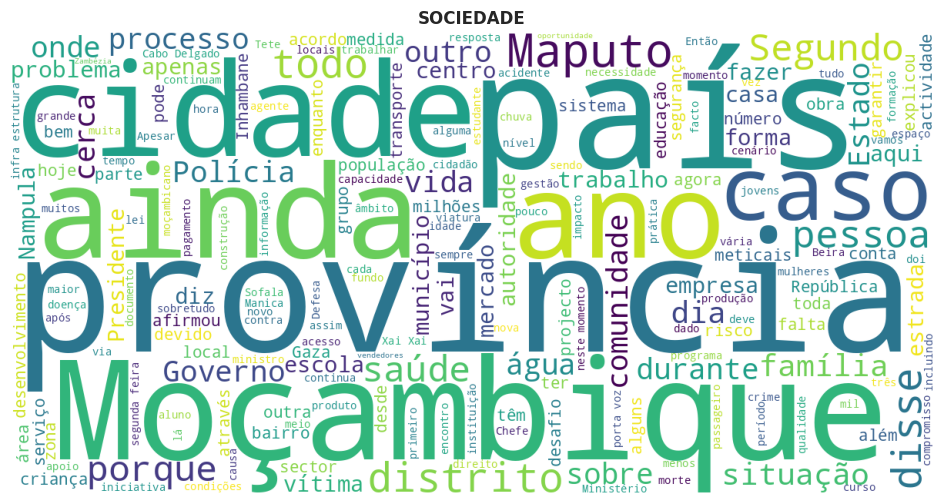

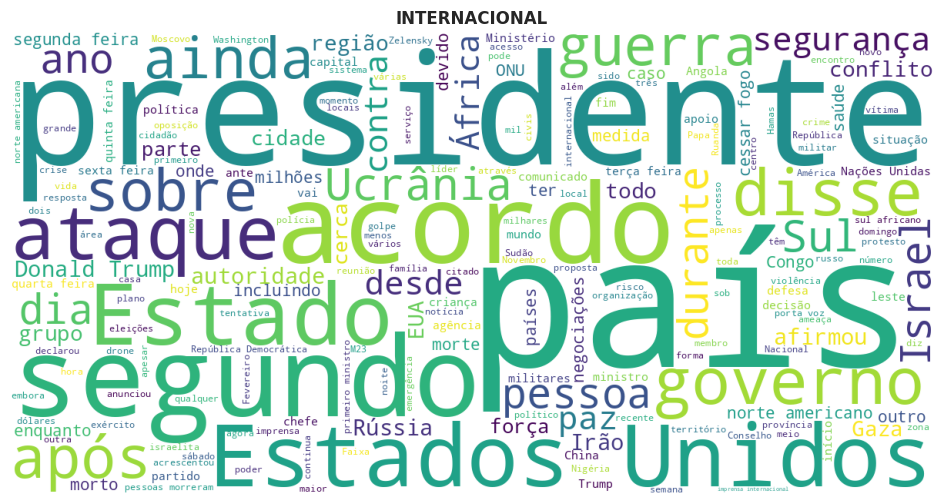

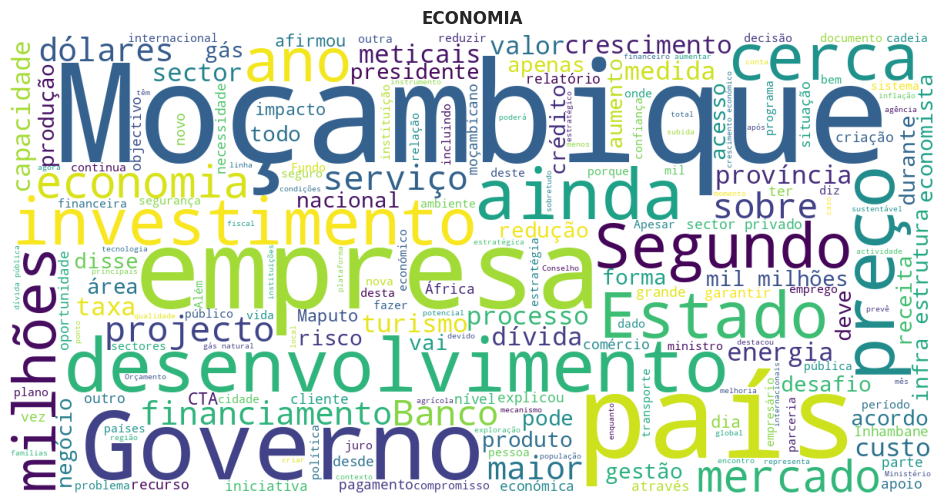

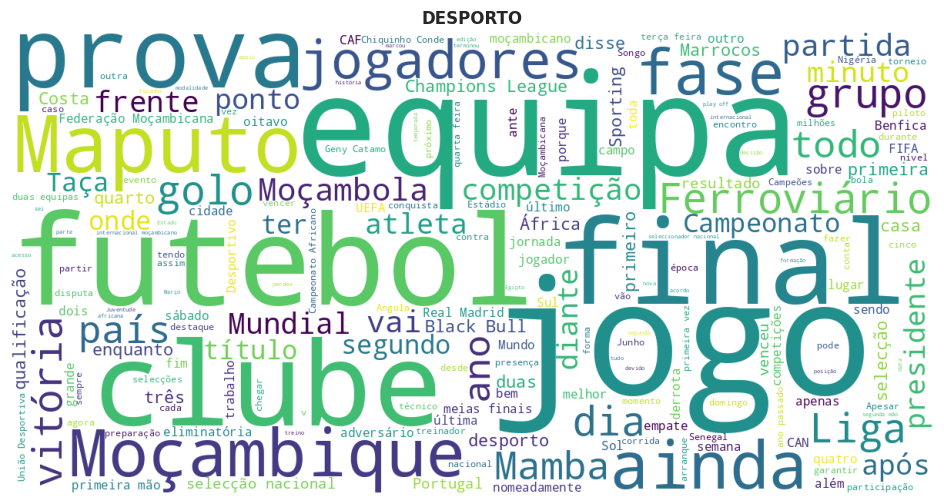

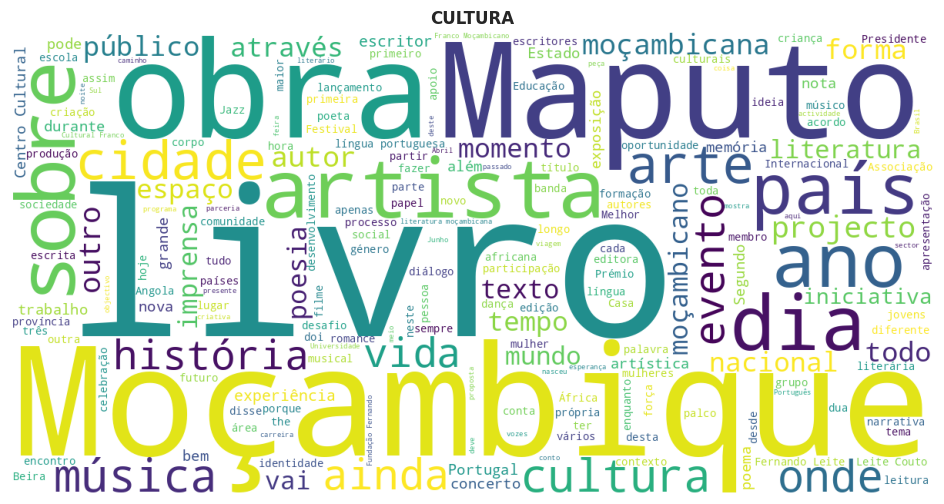

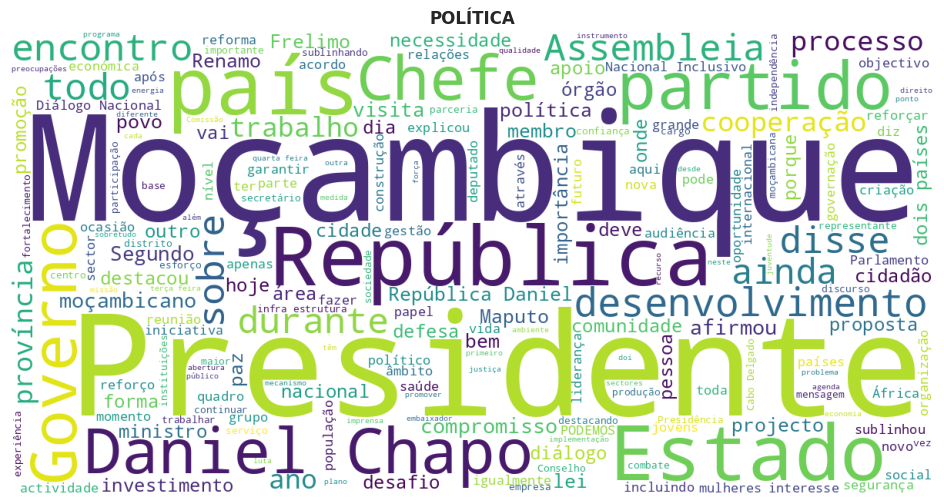

In [234]:
for categoria in noticias["CLASSE"].unique():

    texto = " ".join(
        noticias[
            noticias["CLASSE"] == categoria
        ]["ARTIGO"].astype(str)
    )

    wc = WordCloud(
        width=1200,
        height=600,
        background_color='white',
        stopwords=stop_words
    ).generate(texto)

    plt.figure(figsize=(12,6))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"{categoria}", 
        fontweight="bold"
              )
    plt.show()

---
# V. *Modelagem*

## i. Regressão Logística

Nesta secção, vamos desenvolver um sistema baseado numa combinação de **TF-IDF (Term Frequency–Inverse Document Frequency)** e **Regressão Logística**.

O fluxo de funcionamento pode ser descrito da seguinte forma:

1. Recepção do texto da notícia.
2. Conversão do texto para representação numérica utilizando TF-IDF.
3. Aplicação da Regressão Logística sobre os atributos gerados.
4. Cálculo das probabilidades para cada categoria.
5. Atribuição da categoria com maior probabilidade.

Por exemplo, considere a seguinte notícia:

> "O Banco de Moçambique anunciou novas medidas para controlar a inflação e estabilizar o mercado cambial."

Após a vectorização, termos como **banco**, **inflação**, **mercado** e **cambial** receberão pesos elevados para a categoria **Economia**, aumentando a probabilidade de classificação nessa classe.

Outro exemplo:

> "A selecção nacional venceu o campeonato após uma excelente actuação do treinador e dos jogadores."

Neste caso, termos como **campeonato**, **treinador**, **jogadores** e **selecção** contribuem fortemente para a categoria **Desporto**.

---


In [235]:
# Variáveis
X = noticias["ARTIGO"]
y = noticias["CLASSE"]

# Separação treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Treino: {len(X_train)}")
print(f"Teste : {len(X_test)}")


Treino: 3044
Teste : 761


---
#### Configuração dos Parâmetros do Modelo

#### TF-IDF

* **lowercase=True**
  Converte todas as palavras para letras minúsculas antes do processamento. Isto reduz a duplicação de termos que diferem apenas pela capitalização, por exemplo, "Governo" e "governo", oque permite uma representação mais consistente dos textos.

* **stop_words=None**
  Não remove palavras consideradas comuns (*stop words*). Deve para permitir que o modelo determine automaticamente quais termos possuem valor discriminativo para a classificação das notícias.

* **max_features=20000**
  Limita o vocabulário às 20.000 características mais relevantes encontradas no conjunto de dados. Este valor ajuda a reduzir o custo computacional e evita a inclusão de termos muito raros que tendem a contribuir pouco para a classificação.

* **ngram_range=(1,2)**
  Considera tanto palavras individuais (*unigramas*) como pares consecutivos de palavras (*bigramas*). Esta configuração permite capturar expressões importantes como "mercado financeiro", "equipa nacional" ou "banco central", que possuem maior significado do que palavras isoladas.

#### Regressão Logística

* **max_iter=2000**
  Define o número máximo de iterações utilizadas pelo algoritmo durante o processo de optimização. O valor foi aumentado para 2000 de forma a garantir a convergência do modelo, uma vez que problemas de classificação textual normalmente envolvem um grande número de atributos.

* **random_state=42**
  Fixa a semente aleatória utilizada pelo algoritmo, garantindo que os resultados possam ser reproduzidos em diferentes execuções e facilitando a comparação dos experimentos.


In [236]:
# Pipeline
modelo = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words=None,
            max_features=20000,
            ngram_range=(1,2)
        )
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])


# Treino
modelo.fit(X_train, y_train)

# Previsões
y_pred = modelo.predict(X_test)

# Avaliação
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nRelatório:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8541392904073587

Relatório:

               precision    recall  f1-score   support

      CULTURA       0.97      0.65      0.78        52
     DESPORTO       0.99      0.92      0.96        93
     ECONOMIA       0.75      0.29      0.42        41
INTERNACIONAL       0.94      0.94      0.94       180
     POLÍTICA       0.84      0.60      0.70        77
    SOCIEDADE       0.78      0.95      0.86       318

     accuracy                           0.85       761
    macro avg       0.88      0.73      0.78       761
 weighted avg       0.86      0.85      0.84       761



### Exemplo de uso

In [237]:
texto = """
O Governo anunciou novas medidas para reforçar o sector da saúde
e aumentar o número de médicos nos hospitais públicos.
"""

classe = modelo.predict([texto])[0]

print("Classe prevista:", classe)

Classe prevista: SOCIEDADE


### Interpretação das decisões do modelo

### PCA

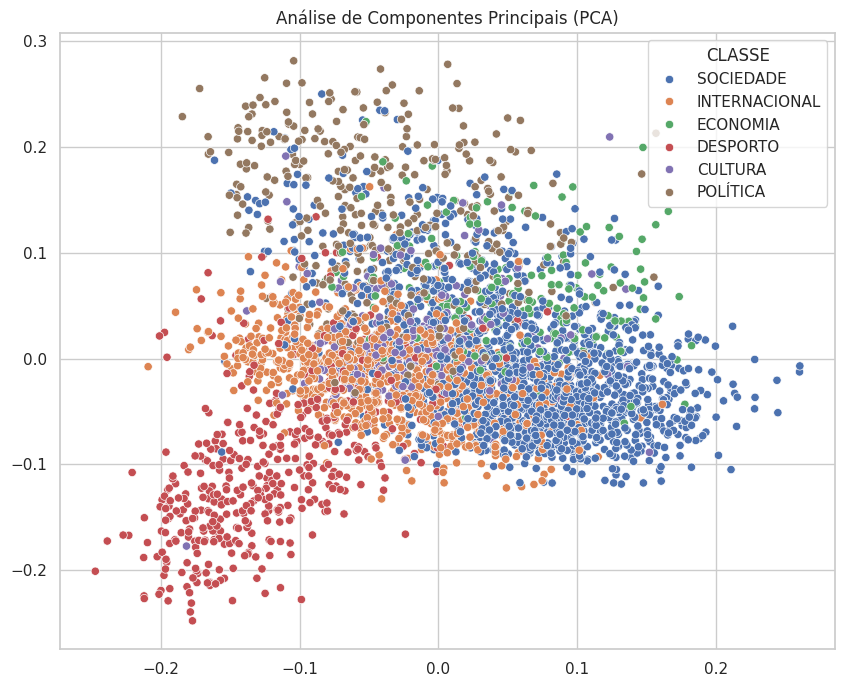

In [238]:
X_vec = tfidf.transform(X)

pca = PCA(n_components=2)

X_red = pca.fit_transform(X_vec.toarray())

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=X_red[:,0],
    y=X_red[:,1],
    hue=y
)

plt.title("Análise de Componentes Principais (PCA)")

plt.show()

### Matriz de confusão

In [239]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=modelo.classes_,
    columns=modelo.classes_
)

cm_df

,CULTURA,DESPORTO,ECONOMIA,INTERNACIONAL,POLÍTICA,SOCIEDADE
CULTURA,34,1,0,1,1,15
DESPORTO,0,86,0,1,0,6
ECONOMIA,0,0,12,3,0,26
INTERNACIONAL,0,0,0,170,0,10
POLÍTICA,0,0,2,0,46,29
SOCIEDADE,1,0,2,5,8,302


### Termos mais importantes por categoria

In [240]:
# Extrair componentes do pipeline
tfidf = modelo.named_steps["tfidf"]
clf = modelo.named_steps["clf"]

# Nomes das features
features = np.array(tfidf.get_feature_names_out())

# Classes
classes = clf.classes_

# Mostrar os termos mais importantes por classe
TOP_N = 20

for i, classe in enumerate(classes):

    coeficientes = clf.coef_[i]

    top_idx = np.argsort(coeficientes)[-TOP_N:]

    print(f"\n{'='*60}")
    print(f"CLASSE: {classe}")
    print(f"{'='*60}")

    for termo, peso in zip(features[top_idx][::-1],
                           coeficientes[top_idx][::-1]):
        print(f"{termo:<25} {peso:.4f}")


CLASSE: CULTURA
livro                     2.3219
cultural                  2.0715
música                    1.9303
artista                   1.7046
artistas                  1.6611
cultura                   1.6572
literatura                1.5697
obra                      1.4692
festival                  1.2491
escritor                  1.2217
arte                      1.2124
couto                     1.2011
língua                    1.1970
artes                     1.1772
poesia                    1.1590
autor                     1.0987
centro cultural           1.0647
maputo                    1.0579
exposição                 1.0577
filme                     1.0572

CLASSE: DESPORTO
futebol                   3.1414
jogo                      2.4881
de futebol                2.0850
prova                     2.0334
desporto                  1.9946
jogos                     1.8370
clube                     1.6992
equipa                    1.6728
jogadores                 1.6026
liga    

In [241]:
TOP_N = 5

resultado = []

for i, classe in enumerate(classes):

    coeficientes = clf.coef_[i]

    top_idx = np.argsort(coeficientes)[-TOP_N:]

    termos = features[top_idx][::-1]

    resultado.append({
        "Classe": classe,
        "Termos importantes": ", ".join(termos)
    })

interpretabilidade = pd.DataFrame(resultado)

print(interpretabilidade)

          Classe                                Termos importantes
0        CULTURA        livro, cultural, música, artista, artistas
1       DESPORTO        futebol, jogo, de futebol, prova, desporto
2       ECONOMIA                  de, empresas, banco, sector, cta
3  INTERNACIONAL          trump, presidente, papa, pessoas, guerra
4       POLÍTICA       partido, chapo, da república, república, da
5      SOCIEDADE  distrito, província, saúde, polícia, distrito de


### Classes frequentemente confundidas

In [242]:
cm_df = pd.DataFrame(
    cm,
    index=classes,
    columns=classes
)

erros = []

for i in range(len(classes)):
    for j in range(len(classes)):

        if i != j and cm[i, j] > 0:

            erros.append({
                "Classe Real": classes[i],
                "Classe Prevista": classes[j],
                "Quantidade": cm[i, j]
            })

erros_df = pd.DataFrame(erros)

erros_df = erros_df.sort_values(
    "Quantidade",
    ascending=False
)

print(erros_df.head(20))

      Classe Real Classe Prevista  Quantidade
10       POLÍTICA       SOCIEDADE          29
7        ECONOMIA       SOCIEDADE          26
3         CULTURA       SOCIEDADE          15
8   INTERNACIONAL       SOCIEDADE          10
14      SOCIEDADE        POLÍTICA           8
5        DESPORTO       SOCIEDADE           6
13      SOCIEDADE   INTERNACIONAL           5
6        ECONOMIA   INTERNACIONAL           3
9        POLÍTICA        ECONOMIA           2
12      SOCIEDADE        ECONOMIA           2
2         CULTURA        POLÍTICA           1
4        DESPORTO   INTERNACIONAL           1
0         CULTURA        DESPORTO           1
1         CULTURA   INTERNACIONAL           1
11      SOCIEDADE         CULTURA           1


### Notícias classificadas incorrectamente

In [243]:
erros_df = pd.DataFrame({
    "texto": X_test,
    "real": y_test,
    "previsto": y_pred
})

erros_df = erros_df[
    erros_df["real"] != erros_df["previsto"]
]

print("Total de erros:", len(erros_df))

Total de erros: 111


In [244]:
for _, linha in erros_df.head(10).iterrows():

    print("\n" + "="*100)
    print("REAL     :", linha["real"])
    print("PREVISTO :", linha["previsto"])
    print("-"*100)

    print(linha["texto"][:600])


REAL     : DESPORTO
PREVISTO : SOCIEDADE
----------------------------------------------------------------------------------------------------
A Federação Internacional de Futebol (FIFA) anunciou oficialmente a realização da 6.ª edição do Exame de Agentes de Futebol, referente ao ano de 2026, conforme comunicado através da Circular n.º 1956, datada de 21 de Janeiro de 2026.

A decisão surge na sequência do elevado número de candidaturas registadas na edição de 2025, que contou com 7745 candidatos em todo o mundo, tendo sido a primeira edição realizada em formato online.

Com vista a aumentar a acessibilidade e dar resposta à crescente procura, a FIFA decidiu alargar o número de sessões de exame, passando de duas para seis datas possí

REAL     : ECONOMIA
PREVISTO : SOCIEDADE
----------------------------------------------------------------------------------------------------
A Empresa Linhas Aéreas de Moçambique (LAM) aumentou o número de aeronaves de passageiros e de carga nas suas ope

<br/>

---
## ii. Naive Bayes

O modelo Naive Bayes baseia-se no Teorema de Bayes e assume que os termos presentes no texto contribuem de forma independente para a classificação da notícia. Embora esta hipótese raramente seja totalmente verdadeira em linguagem natural, o modelo apresenta bom desempenho em tarefas de classificação textual devido à sua simplicidade e eficiência computacional.

Diferentemente da Regressão Logística, que aprende coeficientes para cada atributo, o Naive Bayes aprende as probabilidades condicionais das palavras em cada categoria. Dessa forma, a classificação é realizada com base na combinação das probabilidades associadas aos termos presentes na notícia, permitindo identificar a categoria mais provável para cada documento analisado.

---

In [245]:
X = noticias["ARTIGO"]
y = noticias["CLASSE"]

# Treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Treino: {len(X_train)}")
print(f"Teste : {len(X_test)}")

Treino: 3044
Teste : 761


In [246]:
# Pipeline
stopwords_pt = stopwords.words("portuguese")

modelo_nb = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            max_features=20000,
            ngram_range=(1, 2),
            stop_words=stopwords_pt            
        )
    ),
    (
        "clf",
        MultinomialNB()
    )
])

# Treino
modelo_nb.fit(X_train, y_train)

# Previsões
y_pred = modelo_nb.predict(X_test)

# Métricas
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy:
0.7766097240473062

Classification Report:
               precision    recall  f1-score   support

      CULTURA       1.00      0.38      0.56        52
     DESPORTO       0.99      0.88      0.93        93
     ECONOMIA       0.00      0.00      0.00        41
INTERNACIONAL       0.95      0.89      0.92       180
     POLÍTICA       0.76      0.25      0.37        77
    SOCIEDADE       0.67      0.97      0.79       318

     accuracy                           0.78       761
    macro avg       0.73      0.56      0.60       761
 weighted avg       0.77      0.78      0.74       761



O modelo obteve uma precisão global de **78%**, mas o desempenho não foi uniforme entre as categorias. Algumas classes foram classificadas com elevada eficácia, enquanto outras apresentaram dificuldades significativas.

#### Sociedade
A categoria **Sociedade** obteve um **recall de 97%**, o maior entre todas as classes, oque significa que quase todas as notícias desta categoria foram identificadas correctamente. Contudo, a precisão foi de apenas **67%**, indicando que muitas notícias pertencentes a outras categorias foram classificadas incorrectamente como Sociedade.

Este comportamento mostra que o elevado número de amostras da classe Sociedade a colocam a funcionar como uma categoria "absorvente", que recebe documentos que o modelo não consegue distinguir claramente das restantes categorias.

#### Economia
O resultado mais preocupante encontra-se na categoria **Economia**, que apresentou **precision, recall e F1-score iguais a zero**.

Isto significa que:

* Nenhuma notícia foi correctamente classificada como Economia;
* O modelo não conseguiu aprender padrões suficientemente distintos para esta categoria;
* Todas as notícias económicas foram classificadas como outras classes.

**Em suma**
Os resultados mostram que o modelo consegue classificar adequadamente categorias com vocabulário específico e bem definido, como Desporto e Internacional. Contudo, apresenta dificuldades significativas em classes semanticamente próximas ou menos representadas, especialmente Economia e Política. 

Para este conjunto de dados, o Naive Bayes possui **limitações na separação de categorias que partilham terminologia semelhante**, sendo expectável que modelos como Regressão Logística ou SVM apresentem um desempenho mais equilibrado e robusto.

---

### Matriz de confusão

In [247]:
classes = modelo_nb.named_steps["clf"].classes_

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=classes,
    columns=classes
)

cm_df

,CULTURA,DESPORTO,ECONOMIA,INTERNACIONAL,POLÍTICA,SOCIEDADE
CULTURA,20,1,0,0,0,31
DESPORTO,0,82,0,2,0,9
ECONOMIA,0,0,0,3,0,38
INTERNACIONAL,0,0,0,161,0,19
POLÍTICA,0,0,0,0,19,58
SOCIEDADE,0,0,0,3,6,309


### Classes frequentemente confundidas

In [248]:
erros = []

for i in range(len(classes)):
    for j in range(len(classes)):

        if i != j and cm[i, j] > 0:

            erros.append({
                "Classe Real": classes[i],
                "Classe Prevista": classes[j],
                "Quantidade": cm[i, j]
            })

erros_df = pd.DataFrame(erros)

if len(erros_df) > 0:

    erros_df = erros_df.sort_values(
        "Quantidade",
        ascending=False
    )

    print("\nClasses Mais Confundidas:\n")
    print(erros_df.head(20))


Classes Mais Confundidas:

     Classe Real Classe Prevista  Quantidade
7       POLÍTICA       SOCIEDADE          58
5       ECONOMIA       SOCIEDADE          38
1        CULTURA       SOCIEDADE          31
6  INTERNACIONAL       SOCIEDADE          19
3       DESPORTO       SOCIEDADE           9
9      SOCIEDADE        POLÍTICA           6
8      SOCIEDADE   INTERNACIONAL           3
4       ECONOMIA   INTERNACIONAL           3
2       DESPORTO   INTERNACIONAL           2
0        CULTURA        DESPORTO           1


### Notícias classificadas incorrectamente


In [249]:
erros_noticias = pd.DataFrame({
    "ARTIGO": X_test,
    "REAL": y_test,
    "PREVISTO": y_pred
})

erros_noticias = erros_noticias[
    erros_noticias["REAL"] != erros_noticias["PREVISTO"]
]

print(f"\nTotal de Erros: {len(erros_noticias)}")

# Mostrar alguns exemplos

for _, linha in erros_noticias.head(10).iterrows():

    print("\n" + "="*100)
    print("REAL     :", linha["REAL"])
    print("PREVISTO :", linha["PREVISTO"])
    print("-"*100)
    print(linha["ARTIGO"][:500])


Total de Erros: 170

REAL     : POLÍTICA
PREVISTO : SOCIEDADE
----------------------------------------------------------------------------------------------------
O Presidente da República, Daniel Chapo, exonerou Alexandre Herculano Manjate do cargo de Alto Comissário da República de Moçambique junto da República do Malawi; Jerónimo João Rosa Chivavi do cargo de Alto Comissário da República de Moçambique junto da República do Quénia e da República do Uganda; Maria Gustava do cargo de Embaixador Plenipotenciário da República de Moçambique junto da República Popular da China e da República Democrática da Coreia do Norte.

O Chefe do Estado exonerou ainda Er

REAL     : POLÍTICA
PREVISTO : SOCIEDADE
----------------------------------------------------------------------------------------------------
O Presidente da República,  Daniel Chapo, diz que o diploma não é garantia de emprego e apela às universidades que formem cidadãos críticos e criativos, capazes de responder às necessidades do

### Termos mais importantes por categoria


In [250]:
tfidf = modelo_nb.named_steps["tfidf"]
nb = modelo_nb.named_steps["clf"]

features = np.array(
    tfidf.get_feature_names_out()
)

TOP_N = 15

print("\n\nTERMOS MAIS IMPORTANTES POR CLASSE")

for i, classe in enumerate(nb.classes_):

    print("\n" + "="*70)
    print(f"CLASSE: {classe}")
    print("="*70)

    # log probabilidade das palavras
    probs = nb.feature_log_prob_[i]

    top_idx = np.argsort(probs)[-TOP_N:]

    for termo, score in zip(
        features[top_idx][::-1],
        probs[top_idx][::-1]
    ):
        print(f"{termo:<30} {score:.4f}")



TERMOS MAIS IMPORTANTES POR CLASSE

CLASSE: CULTURA
livro                          -7.6963
cultural                       -7.8791
música                         -8.0548
artista                        -8.0619
artistas                       -8.1246
obra                           -8.1298
maputo                         -8.1600
moçambique                     -8.2027
cultura                        -8.2333
literatura                     -8.2355
couto                          -8.3217
exposição                      -8.3423
sobre                          -8.3474
poesia                         -8.3653
escritor                       -8.3733

CLASSE: DESPORTO
futebol                        -6.9970
jogo                           -7.1212
jogos                          -7.4505
liga                           -7.4527
final                          -7.4578
equipa                         -7.5158
prova                          -7.5195
selecção                       -7.6502
jogadores                      

In [251]:
resumo = []

for i, classe in enumerate(nb.classes_):

    probs = nb.feature_log_prob_[i]

    top_idx = np.argsort(probs)[-5:]

    termos = features[top_idx][::-1]

    resumo.append({
        "Classe": classe,
        "Termos Importantes": ", ".join(termos)
    })

interpretabilidade = pd.DataFrame(resumo)

print("\n")
print(interpretabilidade)



          Classe                                 Termos Importantes
0        CULTURA         livro, cultural, música, artista, artistas
1       DESPORTO                  futebol, jogo, jogos, liga, final
2       ECONOMIA       moçambique, empresas, sector, banco, milhões
3  INTERNACIONAL           presidente, trump, estados, sul, ucrânia
4       POLÍTICA  república, presidente, chapo, moçambique, partido
5      SOCIEDADE         província, moçambique, saúde, cidade, país


<br/>

---

## iii. Linear Support Vector Machine (Linear SVM)

O objectivo do L. SVM é encontrar a fronteira de decisão óptima que separa as diferentes categorias de notícias, maximizando a distância entre os exemplos de classes distintas.

Diferentemente do Naive Bayes, que utiliza probabilidades para efectuar a classificação, o Linear SVM baseia-se na construção de fronteiras de separação entre as categorias. Além disso, o modelo produz coeficientes para cada termo, permitindo identificar quais palavras exercem maior influência na classificação das notícias.


In [252]:
X = noticias["ARTIGO"]
y = noticias["CLASSE"]

# Treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Treino: {len(X_train)}")
print(f"Teste : {len(X_test)}")

Treino: 3044
Teste : 761


In [253]:
# Pipeline
modelo_svm = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            stop_words=None,
            max_features=20000,
            ngram_range=(1,2)
        )
    ),
    (
        "clf",
        LinearSVC(
            random_state=42,
            max_iter=5000
        )
    )
])

# Treino
modelo_svm.fit(X_train, y_train)

# Previsões
y_pred = modelo_svm.predict(X_test)

# Avaliação
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy:
0.8869908015768725

Classification Report:
               precision    recall  f1-score   support

      CULTURA       0.91      0.81      0.86        52
     DESPORTO       0.99      0.97      0.98        93
     ECONOMIA       0.73      0.46      0.57        41
INTERNACIONAL       0.95      0.96      0.95       180
     POLÍTICA       0.82      0.73      0.77        77
    SOCIEDADE       0.85      0.93      0.89       318

     accuracy                           0.89       761
    macro avg       0.88      0.81      0.84       761
 weighted avg       0.88      0.89      0.88       761



Os resultados demonstram que o modelo apresentou um desempenho global satisfatório com **precisão de 88,7%**.

A análise das métricas por categoria revela que o modelo obteve os melhores resultados nas classes **Desporto** e **Internacional**. A categoria **Sociedade** também apresentou um desempenho sólido, com **85% de precisão**, **93% de recall** e **89% de F1-score**.

O desempenho menos expressivo foi observado na categoria **Economia**, que registou **73% de precisão**, **46% de recall** e **57% de F1-score**. O valor reduzido de recall indica que mais de metade das notícias económicas foram classificadas noutras categorias.

De forma geral, o Linear SVM apresentou resultados superiores aos observados no modelo Naive Bayes, conseguindo um melhor equilíbrio entre precisão e recall na maioria das categorias.

---

### Matriz de confusão


In [254]:
classes = modelo_svm.named_steps["clf"].classes_

cm = confusion_matrix(
    y_test,
    y_pred
)

cm_df = pd.DataFrame(
    cm,
    index=classes,
    columns=classes
)

print("\nMatriz de Confusão:")
print(cm_df)


Matriz de Confusão:
               CULTURA  DESPORTO  ECONOMIA  INTERNACIONAL  POLÍTICA  SOCIEDADE
CULTURA             42         1         0              1         1          7
DESPORTO             0        90         0              1         0          2
ECONOMIA             0         0        19              3         0         19
INTERNACIONAL        1         0         0            172         0          7
POLÍTICA             1         0         3              0        56         17
SOCIEDADE            2         0         4              5        11        296


### Classes frequentemente confundidas


In [255]:
erros = []

for i, real in enumerate(classes):

    for j, previsto in enumerate(classes):

        if i != j and cm[i, j] > 0:

            erros.append({
                "Classe Real": real,
                "Classe Prevista": previsto,
                "Quantidade": cm[i, j]
            })

erros_df = pd.DataFrame(erros)

if len(erros_df) > 0:

    erros_df = erros_df.sort_values(
        "Quantidade",
        ascending=False
    )

    print("\nClasses Mais Confundidas:")
    print(erros_df.head(20))



Classes Mais Confundidas:
      Classe Real Classe Prevista  Quantidade
7        ECONOMIA       SOCIEDADE          19
12       POLÍTICA       SOCIEDADE          17
16      SOCIEDADE        POLÍTICA          11
9   INTERNACIONAL       SOCIEDADE           7
3         CULTURA       SOCIEDADE           7
15      SOCIEDADE   INTERNACIONAL           5
14      SOCIEDADE        ECONOMIA           4
11       POLÍTICA        ECONOMIA           3
6        ECONOMIA   INTERNACIONAL           3
13      SOCIEDADE         CULTURA           2
5        DESPORTO       SOCIEDADE           2
0         CULTURA        DESPORTO           1
4        DESPORTO   INTERNACIONAL           1
8   INTERNACIONAL         CULTURA           1
1         CULTURA   INTERNACIONAL           1
2         CULTURA        POLÍTICA           1
10       POLÍTICA         CULTURA           1


### Notícias classificadas incorrectamente


In [256]:
erros_noticias = pd.DataFrame({
    "ARTIGO": X_test,
    "REAL": y_test,
    "PREVISTO": y_pred
})

erros_noticias = erros_noticias[
    erros_noticias["REAL"] != erros_noticias["PREVISTO"]
]

print(f"\nTotal de Erros: {len(erros_noticias)}")

for _, linha in erros_noticias.head(10).iterrows():

    print("\n" + "="*100)

    print("REAL     :", linha["REAL"])
    print("PREVISTO :", linha["PREVISTO"])

    print("-"*100)

    print(linha["ARTIGO"][:500])



Total de Erros: 86

REAL     : SOCIEDADE
PREVISTO : POLÍTICA
----------------------------------------------------------------------------------------------------
As mulheres do sector económico exigiram maior inclusão nos processos de tomada de decisão e na formulação de políticas públicas, durante a sessão de auscultação promovida esta quinta-feira, em Maputo, pela Comissão Técnica para o Diálogo Nacional Inclusivo (COTE), em coordenação com a Fundação para o Desenvolvimento da Comunidade (FDC).

Entre os temas apresentados destacou-se a necessidade de maior integração das mulheres na tomada de decisões em várias áreas de governação no país, sobretudo n

REAL     : POLÍTICA
PREVISTO : ECONOMIA
----------------------------------------------------------------------------------------------------
O Governo prevê arrecadar cerca de 386 mil milhões de Meticais para execução das actividades previstas para 2025. Para cobrir o défice orçamental, de cerca de 127 mil milhões de meticais, o Exec

### Termos mais importantes por categoria


In [257]:
tfidf = modelo_svm.named_steps["tfidf"]
svm = modelo_svm.named_steps["clf"]

features = np.array(
    tfidf.get_feature_names_out()
)

TOP_N = 15

print("\n\nTERMOS MAIS IMPORTANTES POR CLASSE")

for i, classe in enumerate(svm.classes_):

    coef = svm.coef_[i]

    top_idx = np.argsort(coef)[-TOP_N:]

    print("\n" + "="*70)
    print(f"CLASSE: {classe}")
    print("="*70)

    for termo, peso in zip(
        features[top_idx][::-1],
        coef[top_idx][::-1]
    ):
        print(f"{termo:<30} {peso:.4f}")




TERMOS MAIS IMPORTANTES POR CLASSE

CLASSE: CULTURA
música                         1.4970
literatura                     1.3875
cultural                       1.3671
livro                          1.3333
artista                        1.2403
cultura                        1.1185
artistas                       1.0948
festival                       1.0600
filme                          1.0120
poesia                         0.9583
artes                          0.9204
escritores                     0.9163
the                            0.9050
arte                           0.8986
escritor                       0.8628

CLASSE: DESPORTO
futebol                        1.7785
jogo                           1.5569
prova                          1.4720
desporto                       1.4666
clube                          1.3287
jogadores                      1.2527
clubes                         1.1604
de futebol                     1.1506
jogos                          1.0985
torneio         

In [258]:
resumo = []

for i, classe in enumerate(svm.classes_):

    coef = svm.coef_[i]

    top_idx = np.argsort(coef)[-5:]

    termos = features[top_idx][::-1]

    resumo.append({
        "Classe": classe,
        "Termos Importantes": ", ".join(termos)
    })

interpretabilidade = pd.DataFrame(resumo)

print("\n")
print(interpretabilidade)




          Classe                                 Termos Importantes
0        CULTURA       música, literatura, cultural, livro, artista
1       DESPORTO              futebol, jogo, prova, desporto, clube
2       ECONOMIA              empresas, cta, moztech, banco, sector
3  INTERNACIONAL          presidente, trump, papa, guerra, eleições
4       POLÍTICA      chapo, partido, frelimo, da república, renamo
5      SOCIEDADE  distrito, distrito de, moçambique, famílias, z...


### Termos que favorecem e desfavorecem cada classe

In [259]:
for idx, classe in enumerate(svm.classes_):

    coef = svm.coef_[idx]

    top_positivos = np.argsort(coef)[-10:]
    top_negativos = np.argsort(coef)[:10]

    print("\n" + "=" * 80)
    print(f"CLASSE: {classe}")
    print("=" * 80)

    print("\nTermos que favorecem a classe:")

    for termo, peso in zip(
        features[top_positivos][::-1],
        coef[top_positivos][::-1]
    ):
        print(f"{termo:<30} {peso:.4f}")

    print("\nTermos que desfavorecem a classe:")

    for termo, peso in zip(
        features[top_negativos],
        coef[top_negativos]
    ):
        print(f"{termo:<30} {peso:.4f}")


CLASSE: CULTURA

Termos que favorecem a classe:
música                         1.4970
literatura                     1.3875
cultural                       1.3671
livro                          1.3333
artista                        1.2403
cultura                        1.1185
artistas                       1.0948
festival                       1.0600
filme                          1.0120
poesia                         0.9583

Termos que desfavorecem a classe:
presidente                     -0.5193
banco                          -0.4660
está                           -0.4201
desporto                       -0.4056
país                           -0.3969
uma exposição                  -0.3876
esta                           -0.3588
mais                           -0.3462
disse                          -0.3353
diz                            -0.3323

CLASSE: DESPORTO

Termos que favorecem a classe:
futebol                        1.7785
jogo                           1.5569
prova               

<br/>

---

## *VI. Comparação dos Modelos e Escolha do Modelo Final*

### Comparação Global dos Modelos

| Métrica            | Naive Bayes | Regressão Logística | Linear SVM |
| ------------------ | ----------- | ------------------- | ---------- |
| Accuracy           | 77,66%      | 85,41%              | 88,70%     |
| Macro F1-score     | 0,60        | 0,78                | 0,84       |
| Weighted F1-score  | 0,74        | 0,84                | 0,88       |
| Número de Erros    | 170         | 111                 | 86         |
| Interpretabilidade | Média       | Alta                | Alta       |
| Robustez           | Média       | Alta                | Muito Alta |


### Comparação por Categoria

| Categoria     | Naive Bayes | Regressão Logística | Linear SVM |
| ------------- | ----------- | ------------------- | ---------- |
| Cultura       | 0,56        | 0,78                | 0,86       |
| Desporto      | 0,93        | 0,96                | 0,98       |
| Economia      | 0,00        | 0,42                | 0,57       |
| Internacional | 0,92        | 0,94                | 0,95       |
| Política      | 0,37        | 0,70                | 0,77       |
| Sociedade     | 0,79        | 0,86                | 0,89       |

*(Valores correspondem ao F1-score de cada categoria.)*

### Escolha do Modelo Final

Com base nos resultados obtidos, o modelo seleccionado para o sistema final foi o **Linear SVM**.

Esta decisão foi fundamentada nos seguintes factores:

* Maior accuracy global (88,70%);
* Menor número de classificações incorrectas (86 erros);
* Melhor Macro F1-score (0,84);
* Melhor desempenho em todas as categorias avaliadas;
* Melhor capacidade de distinguir classes semanticamente semelhantes;
* Maior robustez e capacidade de generalização.

Embora a Regressão Logística tenha apresentado resultados próximos e possua elevada interpretabilidade, o Linear SVM demonstrou desempenho superior em todos os indicadores considerados relevantes para o problema em estudo.

Dessa forma, conclui-se que o Linear SVM representa a solução mais adequada para a classificação automática de notícias neste projecto.


</br>

---

# *VI. Conclusão*

Este estudo teve como objectivo desenvolver e avaliar modelos de ML para a classificação automática de notícias em diferentes categorias temáticas, para a organização e processamento eficiente de grandes volumes de informação textual.

---

## Metodologia

A investigação foi desenvolvida em cinco fases principais:

1. **Recolha e Preparação dos Dados**: Obtenção do conjunto de notícias e organização das categorias utilizadas na classificação.

2. **Pré-processamento Textual**: Limpeza dos textos, remoção de caracteres especiais, normalização e preparação dos documentos para análise computacional.

3. **Extracção de Características**: Conversão dos textos para representação numérica utilizando a técnica TF-IDF (*Term Frequency-Inverse Document Frequency*).

4. **Treino e Avaliação dos Modelos**: Implementação e comparação de diferentes algoritmos de classificação supervisionada.

5. **Análise Comparativa dos Resultados**: Avaliação do desempenho dos modelos através das métricas Accuracy, Precision, Recall e F1-Score.

---

## Principais Descobertas

* Os resultados demonstraram que os modelos são capazes de classificar notícias com elevado nível de precisão.

* A representação textual baseada em TF-IDF mostrou-se eficaz na captura das características mais relevantes dos documentos.

* Verificou-se que categorias com vocabulário mais específico e distintivo apresentaram maiores taxas de acerto, enquanto categorias com conteúdos semanticamente semelhantes registaram maior número de erros de classificação.

* A análise das matrizes de confusão revelou que a maioria dos erros ocorreu entre categorias com temas relacionados, demonstrando que a sobreposição temática influencia directamente o desempenho dos classificadores.

---

## Limitações do Estudo

| Limitação                              | Descrição                                                                                                                   |
| -------------------------------------- | --------------------------------------------------------------------------------------------------------------------------- |
| **Representação Textual Limitada**     | O estudo utilizou exclusivamente TF-IDF, não explorando representações semânticas mais avançadas.                           |
| **Dependência do Conjunto de Dados**   | O desempenho dos modelos está condicionado à qualidade, dimensão e balanceamento do conjunto de notícias utilizado.         |
| **Sem Informação Contextual Profunda** | Os modelos tradicionais apresentam limitações na compreensão de contexto e significado implícito das palavras.              |
| **Categorias Semanticamente Próximas** | Algumas classes apresentam características semelhantes, aumentando a probabilidade de classificações incorrectas.           |
| **Generalização Limitada**             | O desempenho pode variar quando aplicado a notícias provenientes de fontes ou períodos diferentes dos utilizados no treino. |

---

## Recomendações para Pesquisas Futuras

* **Utilização de Modelos Baseados em Transformers**: Avaliar arquitecturas modernas como BERT, RoBERTa e DistilBERT para melhorar a compreensão contextual dos textos.

* **Expansão do Conjunto de Dados**: Incorporar notícias provenientes de diferentes fontes, idiomas e períodos temporais para aumentar a capacidade de generalização dos modelos.

* **Análise de Interpretabilidade**: Aplicar técnicas como SHAP e LIME para compreender melhor os factores que influenciam as decisões dos classificadores.

* **Classificação Multirrótulo**: Investigar abordagens que permitam associar uma mesma notícia a múltiplas categorias simultaneamente.

* **Implementação em Tempo Real**: Desenvolver sistemas capazes de classificar notícias automaticamente à medida que são publicadas em plataformas digitais.

---

## Por Fim

O modelo seleccionado apresentou desempenho satisfatório na tarefa proposta e confirmou a viabilidade da utilização destas técnicas em sistemas inteligentes de organização e recuperação de informação. Apesar das limitações identificadas, o estudo estabelece uma base sólida para futuras investigações e para o desenvolvimento de aplicações práticas na área de mineração de textos e análise automática de conteúdos jornalísticos.
